# SHAP-IMV — Adult Income

Exact Shapley attribution with IMV as the coalition value, on the UCI Adult
Income census extract (binary: income > 50K).

**Pipeline**: download from UCI → preprocess → standardise → 10 seeds × 3
estimators × exact power set → aggregate.

No data is committed; `fetch_ucirepo` downloads into a user-level cache.
Full documentation: `documentation/examples/shap_imv/adult_income.md`.

In [1]:
import os, sys, tempfile, warnings, itertools
from pathlib import Path

_PATH_DISPLAY_ROOT = Path()

def relative_path(path, *, start=None):
    """Return a display-only path relative to an explicit local anchor."""
    anchor = Path(start) if start is not None else _PATH_DISPLAY_ROOT
    try:
        relative = os.path.relpath(Path(path).expanduser().resolve(),
                                   start=anchor.expanduser().resolve())
    except ValueError:  # Paths on different Windows drives cannot be relativized.
        relative = Path(path).name
    return Path(relative).as_posix()

def _relative_warning_text(message):
    text = str(message)
    roots = {Path.home(), Path(sys.prefix), Path(sys.base_prefix),
             _PATH_DISPLAY_ROOT, Path(tempfile.gettempdir())}
    for root in sorted(roots, key=lambda value: len(str(value)), reverse=True):
        absolute = str(root.expanduser().resolve())
        text = text.replace(absolute, relative_path(absolute))
    return text

def _show_relative_warning(message, category, filename, lineno, file=None, line=None):
    stream = file if file is not None else sys.stderr
    warning_text = _relative_warning_text(message)
    print(f"{relative_path(filename)}:{lineno}: {category.__name__}: {warning_text}", file=stream)

warnings.showwarning = _show_relative_warning

%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# No dataset is stored in this repository. Everything downloads on demand into a
# user-level cache outside the working tree.
CACHE = Path(os.environ.get("IMV_CACHE_HOME", Path.home() / ".cache" / "imv"))
CACHE.mkdir(parents=True, exist_ok=True)

ARTIFACTS = Path(os.environ.get("IMV_ARTIFACT_CACHE", CACHE / "notebook_artifacts")) / "shap_imv_adult_income"
RESULTS = ARTIFACTS / "results"; RESULTS.mkdir(parents=True, exist_ok=True)
PROJECT_ROOT = next(
    (path for path in (Path.cwd(), *Path.cwd().parents)
     if (path / "requirements.txt").is_file() and (path / "src").is_dir()),
    Path.cwd(),
)
FIGURES = Path(os.environ.get(
    "IMV_FIGURE_DIR", PROJECT_ROOT / "output" / "figures"
))
FIGURES.mkdir(parents=True, exist_ok=True)
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))
from figure_utils import (
    COLORMAP, configure_plotting, spectral_colors,
    save_publication_figure as save_figure,
)
configure_plotting()
FORCE_RECOMPUTE = os.environ.get("IMV_FORCE_RECOMPUTE", "0").strip().lower() in {
    "1", "true", "yes",
}

# Ten seeds, as required for any reported IMV result. The seed drives the fold
# split and the estimator, so every number below is a mean over ten independent
# fold partitions.
SEEDS = [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]
N_SPLITS = 5

import imvpy
from imvpy import BinaryIMV

IMVPY_SOURCE = Path(imvpy.__file__).resolve().parent
print(f"imvpy {imvpy.__version__} from {relative_path(IMVPY_SOURCE)}")


imvpy 1.2.0 from ../../../../../../../../anaconda3/lib/python3.12/site-packages/imvpy


## 1. Download

Nothing is read from the repository.

In [2]:
from ucimlrepo import fetch_ucirepo
DATASET, TITLE = "adult_income", "Adult Income"
raw = fetch_ucirepo(id=2)
frame = raw.data.features.copy()
frame["target"] = raw.data.targets.iloc[:, 0].astype(str).str.strip().str.rstrip(".")
print(frame.shape, frame["target"].value_counts().to_dict())
frame.head()

(48842, 15) {'<=50K': 37155, '>50K': 11687}


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,target
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## 2. Preprocess

Every transformation is applied here and stated in the docs.

In [3]:
# Binary target, then six features chosen to span demographic, human-capital and
# labour-supply signal while keeping 2**6 = 64 coalitions affordable.
frame["target"] = (frame["target"] == ">50K").astype(int)
FEATURES = ["age", "education-num", "hours-per-week", "capital-gain",
            "sex_female", "married"]
frame["sex_female"] = (frame["sex"].astype(str).str.strip() == "Female").astype(int)
frame["married"] = frame["marital-status"].astype(str).str.strip().str.startswith("Married").astype(int)
data = frame[FEATURES + ["target"]].apply(pd.to_numeric, errors="coerce").dropna()
print(data.shape, "positive rate:", round(data["target"].mean(), 4))
data.head()

(48842, 7) positive rate: 0.2393


,age,education-num,hours-per-week,capital-gain,sex_female,married,target
0,39,13,40,2174,0,0,0
1,50,13,13,0,0,1,0
2,38,9,40,0,0,0,0
3,53,7,40,0,0,1,0
4,28,13,40,0,1,1,0


## 3. Estimators and budget

In [4]:
from joblib import Parallel, delayed, parallel_config
from tqdm.auto import tqdm

# Parallelise the 30 independent seed/model evaluations. Each BinaryIMV run stays
# single-process to avoid nested pools and repeated worker start-up for 64 coalitions.
MODEL_PARAMETERS = {
    "logistic_regression": {"max_iter": 5000},
    "xgboost": {"n_estimators": 60, "max_depth": 3, "learning_rate": 0.2,
                "verbosity": 0, "tree_method": "hist", "n_jobs": 1},
    "lightgbm": {"n_estimators": 60, "max_depth": 3, "learning_rate": 0.2,
                 "verbose": -1, "n_jobs": 1},
}
MODEL_NAMES = tuple(MODEL_PARAMETERS)
CPU_COUNT = (len(os.sched_getaffinity(0)) if hasattr(os, "sched_getaffinity")
             else (os.cpu_count() or 1))
DEFAULT_OUTER_JOBS = min(15, max(1, CPU_COUNT - 1))
OUTER_N_JOBS = int(os.environ.get("IMV_N_JOBS", DEFAULT_OUTER_JOBS))
if OUTER_N_JOBS < 1:
    raise ValueError("IMV_N_JOBS must be a positive integer")
OUTER_N_JOBS = min(OUTER_N_JOBS, len(SEEDS) * len(MODEL_NAMES))

def model_factories(seed):
    """Three estimator families, deliberately small so the exact power set is affordable."""
    return {
        "logistic_regression": lambda: LogisticRegression(
            random_state=seed, **MODEL_PARAMETERS["logistic_regression"]),
        "xgboost": lambda: XGBClassifier(
            random_state=seed, **MODEL_PARAMETERS["xgboost"]),
        "lightgbm": lambda: LGBMClassifier(
            random_state=seed, **MODEL_PARAMETERS["lightgbm"]),
    }

print(f"outer workers: {OUTER_N_JOBS}; BinaryIMV workers per task: 1")


outer workers: 15; BinaryIMV workers per task: 1


## 4. Exact SHAP-IMV over ten seeds

Each value is a mean over ten independent fold partitions; `std` is the spread across seeds, which describes stability and is **not** a confidence interval. Seed/model jobs run in parallel and are checkpointed individually, so an interrupted execution resumes completed work.

In [5]:
import hashlib, json
from time import perf_counter

# Features are standardised because IMV reads probabilities, and unscaled inputs
# leave logistic regression unconverged, which would score a half-optimised model.
def scaled(frame, features):
    out = frame.copy()
    out[features] = StandardScaler().fit_transform(out[features])
    return out

# Standardisation is fit once on the full dataset: with no row subsampling the
# seed no longer selects rows, only the fold partition and the estimator.
frame = scaled(data, FEATURES)

data_fingerprint = hashlib.sha256(
    pd.util.hash_pandas_object(frame[FEATURES + ["target"]], index=True)
    .to_numpy().tobytes()
).hexdigest()
run_config = {
    "data_sha256": data_fingerprint,
    "features": FEATURES,
    "imvpy_version": imvpy.__version__,
    "model_parameters": MODEL_PARAMETERS,
    "n_splits": N_SPLITS,
    "split_method": "stratified_kfold",
}
RUN_SIGNATURE = hashlib.sha256(
    json.dumps(run_config, sort_keys=True, separators=(",", ":")).encode()
).hexdigest()[:12]
CHECKPOINTS = RESULTS / "checkpoints" / RUN_SIGNATURE
CHECKPOINTS.mkdir(parents=True, exist_ok=True)
EXPECTED_FEATURES = (*FEATURES, "__full_model_imv__")
RESULT_COLUMNS = ["seed", "model", "feature", "shap_imv"]

def checkpoint_path(seed, model_name):
    return CHECKPOINTS / f"seed_{seed}_{model_name}.csv"

def write_csv_atomic(table, path):
    """Replace a CSV only after its complete contents reach the same directory."""
    temporary = path.with_name(f".{path.name}.{os.getpid()}.tmp")
    try:
        table.to_csv(temporary, index=False)
        os.replace(temporary, path)
    finally:
        temporary.unlink(missing_ok=True)

def read_checkpoint(seed, model_name):
    checkpoint = pd.read_csv(checkpoint_path(seed, model_name))
    if list(checkpoint.columns) != RESULT_COLUMNS:
        raise ValueError(f"invalid checkpoint: {checkpoint_path(seed, model_name).name}")
    valid = (
        len(checkpoint) == len(EXPECTED_FEATURES),
        checkpoint["seed"].eq(seed).all(),
        checkpoint["model"].eq(model_name).all(),
        set(checkpoint["feature"]) == set(EXPECTED_FEATURES),
        checkpoint["feature"].is_unique,
        np.isfinite(checkpoint["shap_imv"].to_numpy(dtype=float)).all(),
    )
    if not all(valid):
        raise ValueError(f"invalid checkpoint: {checkpoint_path(seed, model_name).name}")
    return checkpoint

def evaluate_seed_model(seed, model_name):
    started = perf_counter()
    evaluator = BinaryIMV(
        frame, "target", FEATURES, model_factories(seed)[model_name],
        split_method="stratified_kfold", n_splits=N_SPLITS,
        random_seed=seed, n_jobs=1, verbose=False,
    )
    with warnings.catch_warnings():
        warnings.filterwarnings(
            "ignore",
            message=("X does not have valid feature names, but "
                     "LGBMClassifier was fitted with feature names"),
            category=UserWarning,
        )
        evaluator.run_evaluation()
    rows = [{
        "seed": seed, "model": model_name, "feature": feature,
        "shap_imv": evaluator.calculate_imvshapley_value(feature),
    } for feature in FEATURES]
    rows.append({
        "seed": seed, "model": model_name, "feature": "__full_model_imv__",
        "shap_imv": evaluator.all_combinations_imv[tuple(FEATURES)][0],
    })
    result = pd.DataFrame(rows, columns=RESULT_COLUMNS)
    write_csv_atomic(result, checkpoint_path(seed, model_name))
    return result, perf_counter() - started

jobs = [(seed, model_name) for seed in SEEDS for model_name in MODEL_NAMES]
result_tables, pending = [], []
for seed, model_name in jobs:
    if FORCE_RECOMPUTE:
        pending.append((seed, model_name))
        continue
    try:
        result_tables.append(read_checkpoint(seed, model_name))
    except (FileNotFoundError, OSError, ValueError, pd.errors.ParserError) as error:
        pending.append((seed, model_name))
        if not isinstance(error, FileNotFoundError):
            print(f"recomputing {model_name} seed {seed}: {error}")

cached = len(result_tables)
mode = "fresh" if FORCE_RECOMPUTE else "resume"
print(f"{mode} mode; run {RUN_SIGNATURE}: {cached}/{len(jobs)} jobs restored; "
      f"running {len(pending)} with {OUTER_N_JOBS} workers")
if pending:
    with parallel_config(backend="loky", inner_max_num_threads=1):
        stream = Parallel(
            n_jobs=OUTER_N_JOBS, return_as="generator_unordered",
            batch_size=1, pre_dispatch=OUTER_N_JOBS,
        )(delayed(evaluate_seed_model)(seed, model_name)
          for seed, model_name in pending)
        with tqdm(total=len(jobs), initial=cached, desc="seed/model evaluations",
                  unit="job") as progress:
            for result, elapsed in stream:
                result_tables.append(result)
                progress.set_postfix_str(
                    f"{result.iloc[0]['model']} seed {result.iloc[0]['seed']} "
                    f"{elapsed:.1f}s")
                progress.update()

if len(result_tables) != len(jobs):
    raise RuntimeError(f"expected {len(jobs)} results, found {len(result_tables)}")
raw = pd.concat(result_tables, ignore_index=True)
model_order = {name: index for index, name in enumerate(MODEL_NAMES)}
feature_order = {name: index for index, name in enumerate(EXPECTED_FEATURES)}
raw = (raw.assign(_model=raw.model.map(model_order),
                  _feature=raw.feature.map(feature_order))
       .sort_values(["seed", "_model", "_feature"])
       .drop(columns=["_model", "_feature"]).reset_index(drop=True))
write_csv_atomic(raw, RESULTS / f"{DATASET}_shap_imv_by_seed.csv")
summary = (raw[raw.feature != "__full_model_imv__"]
           .groupby(["model", "feature"])["shap_imv"]
           .agg(["mean", "std"]).reset_index()
           .sort_values(["model", "mean"], ascending=[True, False]))
write_csv_atomic(summary, RESULTS / f"{DATASET}_shap_imv_summary.csv")
summary


fresh mode; run 5ac12f52a111: 0/30 jobs restored; running 30 with 15 workers


seed/model evaluations:   0%|          | 0/30 [00:00<?, ?job/s]

  0%|          | 0/64 [00:00<?, ?it/s]

  0%|          | 0/64 [00:00<?, ?it/s]

  0%|          | 0/64 [00:00<?, ?it/s]

...

  0%|          | 0/64 [00:00<?, ?it/s]

  0%|          | 0/64 [00:00<?, ?it/s]

  0%|          | 0/64 [00:00<?, ?it/s]

  0%|          | 0/64 [00:00<?, ?it/s]

,model,feature,mean,std
4,lightgbm,married,0.0530,0.000000
1,lightgbm,capital-gain,0.0470,0.000000
2,lightgbm,education-num,0.0370,0.000000
0,lightgbm,age,0.0290,0.000000
3,lightgbm,hours-per-week,0.0160,0.000000
5,lightgbm,sex_female,0.0100,0.000000
10,logistic_regression,married,0.0610,0.000000
8,logistic_regression,education-num,0.0420,0.000000
7,logistic_regression,capital-gain,0.0320,0.000000
6,logistic_regression,age,0.0130,0.000000


## 5. Figure

A negative bar means the feature *reduced* held-out information — it does not indicate the negative class.

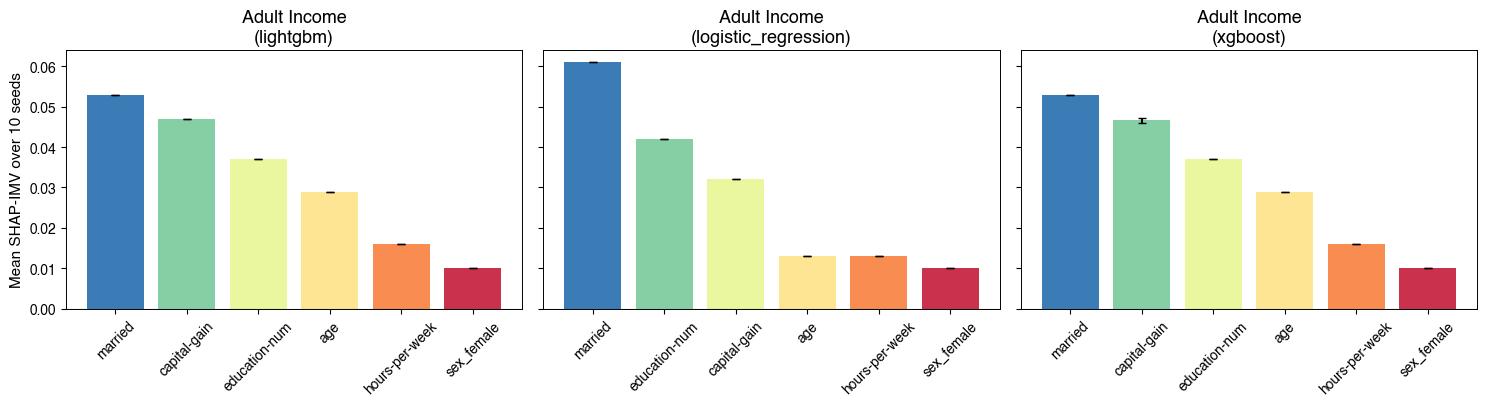

{'pdf': '../../../../CharlieRahal Dropbox/Charlie RAHAL/imv/imv_ml/new/IMV_ML/output/figures/shap_imv_adult_income__shap_imv.pdf'}

In [2]:
models = list(summary["model"].unique())
fig, axes = plt.subplots(1, len(models), figsize=(5 * len(models), 4.2), sharey=True)
axes = np.atleast_1d(axes)
for ax, name in zip(axes, models):
    part = summary[summary.model == name].sort_values("mean", ascending=False)
    ax.bar(part["feature"], part["mean"], yerr=part["std"].fillna(0),
           capsize=3, color=spectral_colors(len(part)))
    ax.set_title(f"{TITLE}\n({name})")
    ax.tick_params(axis="x", rotation=45)
    ax.axhline(0, color="0.4", linewidth=0.8)
axes[0].set_ylabel(f"Mean SHAP-IMV over {len(SEEDS)} seeds")
fig.tight_layout()
paths = {file_format: relative_path(path, start=ARTIFACTS)
         for file_format, path in save_figure(
             fig, FIGURES / "shap_imv_adult_income__shap_imv"
         ).items()}
plt.show()
paths
